In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary

try :
    import torch_directml
    device = torch_directml.device(0) 
except:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(device)

privateuseone:0


https://www.kaggle.com/datasets/team-ai/spam-text-message-classification

In [3]:
data_path = 'spam.csv'

df = pd.read_csv(data_path)
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.isna().sum()

Category    0
Message     0
dtype: int64

In [5]:
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})
df['Category'].value_counts()

Category
0    4825
1     747
Name: count, dtype: int64

In [6]:
X = df['Message']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=0)

print(f'Train size : {X_train.shape[0]}')
print(f'Validation size : {X_val.shape[0]}')
print(f'Test size : {X_test.shape[0]}')

Train size : 3900
Validation size : 836
Test size : 836


In [7]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained("bert-base-uncased")

c:\Users\Flo pro\Documents\Portfolio\env\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [8]:
class dataset(Dataset):
    def __init__(self, X, y):
        # Transform words into values (tokenizer)
        self.X = [tokenizer(x, 
                            max_length=100,             # Nombre de mots voulut
                            truncation=True,            # Arrête à max_length (coupe le reste)
                            padding='max_length',       # Ajoute des 0 si inférieur à max_length
                            return_tensors='pt')         # Retourne la valeur en PyTorch tensor
                            .to(device)
                            for x in X]
        self.y = torch.tensor(list(y), dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]
    
# Création des 3 ensembles
train_dataset = dataset(X_train, y_train)
val_dataset = dataset(X_test, y_test)
test_dataset = dataset(X_val, y_val)

In [9]:
BATCH_SIZE = 32
LR = 1e-3
EPOCHS = 10

In [10]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [11]:
class MyModel(nn.Module):
    def __init__(self, bert):
        super(MyModel, self).__init__()

        self.bert = bert
        self.dropout = nn.Dropout(0.25)
        self.linear1 = nn.Linear(768, 384)
        self.linear2 = nn.Linear(384, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        pooled_output = self.bert(input_ids, attention_mask, return_dict=False)[0][:,0]
        output = self.linear1(pooled_output)
        output = self.dropout(output)
        output = self.linear2(output)
        output = self.sigmoid(output)
        return output

In [12]:
for param in bert_model.parameters():
    param.requires_grad = False

model = MyModel(bert_model).to(device)

In [13]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=LR)

In [14]:
total_loss_train_plot = []
total_acc_train_plot = []
total_loss_val_plot = []
total_acc_val_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_loss_val = 0
    total_acc_val = 0

    for indx, data in enumerate(train_dataloader):
        inputs, labels = data
        inputs.to(device)
        labels.to(device)

        prediction = model(inputs['input_ids'].squeeze(1), inputs['attention_mask'].squeeze(1)).squeeze(1)
        batch_loss = criterion(prediction, labels)
        total_loss_train += batch_loss.item()

        acc = (prediction.round() == labels).sum().item()
        total_acc_train += acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    with torch.no_grad():
        for indx, data in enumerate(val_dataloader):
            inputs, labels = data
            inputs.to(device)
            labels.to(device)

            prediction = model(inputs['input_ids'].squeeze(1), inputs['attention_mask'].squeeze(1)).squeeze(1)
            batch_loss = criterion(prediction, labels)
            total_loss_val += batch_loss.item()

            acc = (prediction.round() == labels).sum().item()
            total_acc_val += acc

    len_train = len(train_dataset)
    len_val = len(val_dataset)

    total_loss_train_plot.append(round(total_loss_train/len_train, 4))
    total_loss_val_plot.append(round(total_loss_val/len_val, 4))  

    total_acc_train_plot.append(round((total_acc_train / len_train) * 100, 4))
    total_acc_val_plot.append(round((total_acc_val / len_val) * 100, 4))  
    
    print('='*25)
    print(f''' Epoch: {epoch+1}/{EPOCHS}, 
    Train Loss: {round(total_loss_train / len_train, 4)}, Train Accuracy: {round((total_acc_train / len_train) * 100, 4)}%
    Validation Loss: {round(total_loss_val / len_val, 4)}, Validation Accuracy: {round((total_acc_val / len_val) * 100, 4)}%
    ''')

c:\Users\Flo pro\Documents\Portfolio\env\Lib\site-packages\torch\nn\functional.py:3172: UserWarning: The operator 'aten::binary_cross_entropy' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  return torch._C._nn.binary_cross_entropy(input, target, weight, reduction_enum)


 Epoch: 1/10, 
    Train Loss: 0.0028, Train Accuracy: 96.7692%
    Validation Loss: 0.0013, Validation Accuracy: 98.6842%
    
 Epoch: 2/10, 
    Train Loss: 0.0014, Train Accuracy: 98.6923%
    Validation Loss: 0.001, Validation Accuracy: 99.1627%
    
 Epoch: 3/10, 
    Train Loss: 0.001, Train Accuracy: 99.0256%
    Validation Loss: 0.0011, Validation Accuracy: 99.0431%
    
 Epoch: 4/10, 
    Train Loss: 0.0008, Train Accuracy: 99.0769%
    Validation Loss: 0.0016, Validation Accuracy: 98.2057%
    
 Epoch: 5/10, 
    Train Loss: 0.0007, Train Accuracy: 99.2308%
    Validation Loss: 0.0011, Validation Accuracy: 98.8038%
    
 Epoch: 6/10, 
    Train Loss: 0.0008, Train Accuracy: 99.1538%
    Validation Loss: 0.0012, Validation Accuracy: 99.0431%
    
 Epoch: 7/10, 
    Train Loss: 0.0005, Train Accuracy: 99.3077%
    Validation Loss: 0.001, Validation Accuracy: 98.9234%
    
 Epoch: 8/10, 
    Train Loss: 0.0008, Train Accuracy: 99.1282%
    Validation Loss: 0.0025, Validation Acc

In [17]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0

    for indx, data in enumerate(val_dataloader):
        inputs, labels = data
        inputs.to(device)
        labels.to(device)

        prediction = model(inputs['input_ids'].squeeze(1), inputs['attention_mask'].squeeze(1)).squeeze(1)
        batch_loss = criterion(prediction, labels)
        total_loss_test += batch_loss.item()

        acc = (prediction.round() == labels).sum().item()
        total_acc_test += acc

        len_test = len(test_dataset)   
        avg_loss_test = total_loss_test / len_test
        avg_acc_test = (total_acc_test / len_test) * 100

    print(f'''Test Loss: {round(avg_loss_test, 4)}, Test Accuracy: {round(avg_acc_test, 4)}%''')

Test Loss: 0.0011, Test Accuracy: 98.8038%


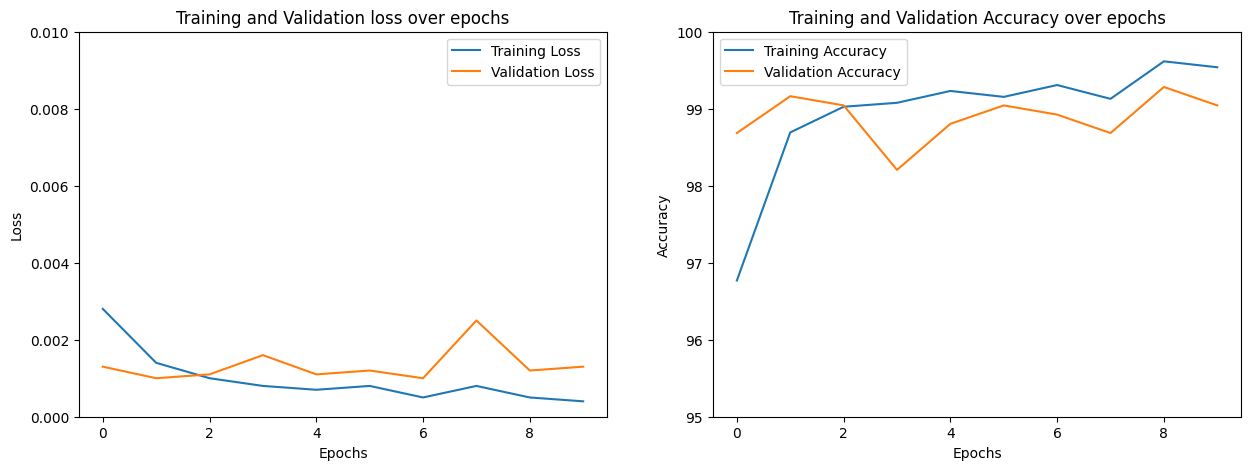

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

ax[0].plot(total_loss_train_plot, label='Training Loss')
ax[0].plot(total_loss_val_plot, label='Validation Loss')
ax[0].set_title('Training and Validation loss over epochs')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_ylim([0, 0.01])
ax[0].legend()

ax[1].plot(total_acc_train_plot, label='Training Accuracy')
ax[1].plot(total_acc_val_plot, label='Validation Accuracy')
ax[1].set_title('Training and Validation Accuracy over epochs')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim([95, 100])
ax[1].legend()

plt.show()